In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Video
import math
import numpy as np
import sys
import os

module_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import functions
import plot_config as pc

pc.apply_custom_mpl_settings()

<h1><span style="color:orange">Numerical Simulation Laboratory (NSL)</span></h1>

<h2><span style="color:green">Numerical Exercise 9</span></h2>

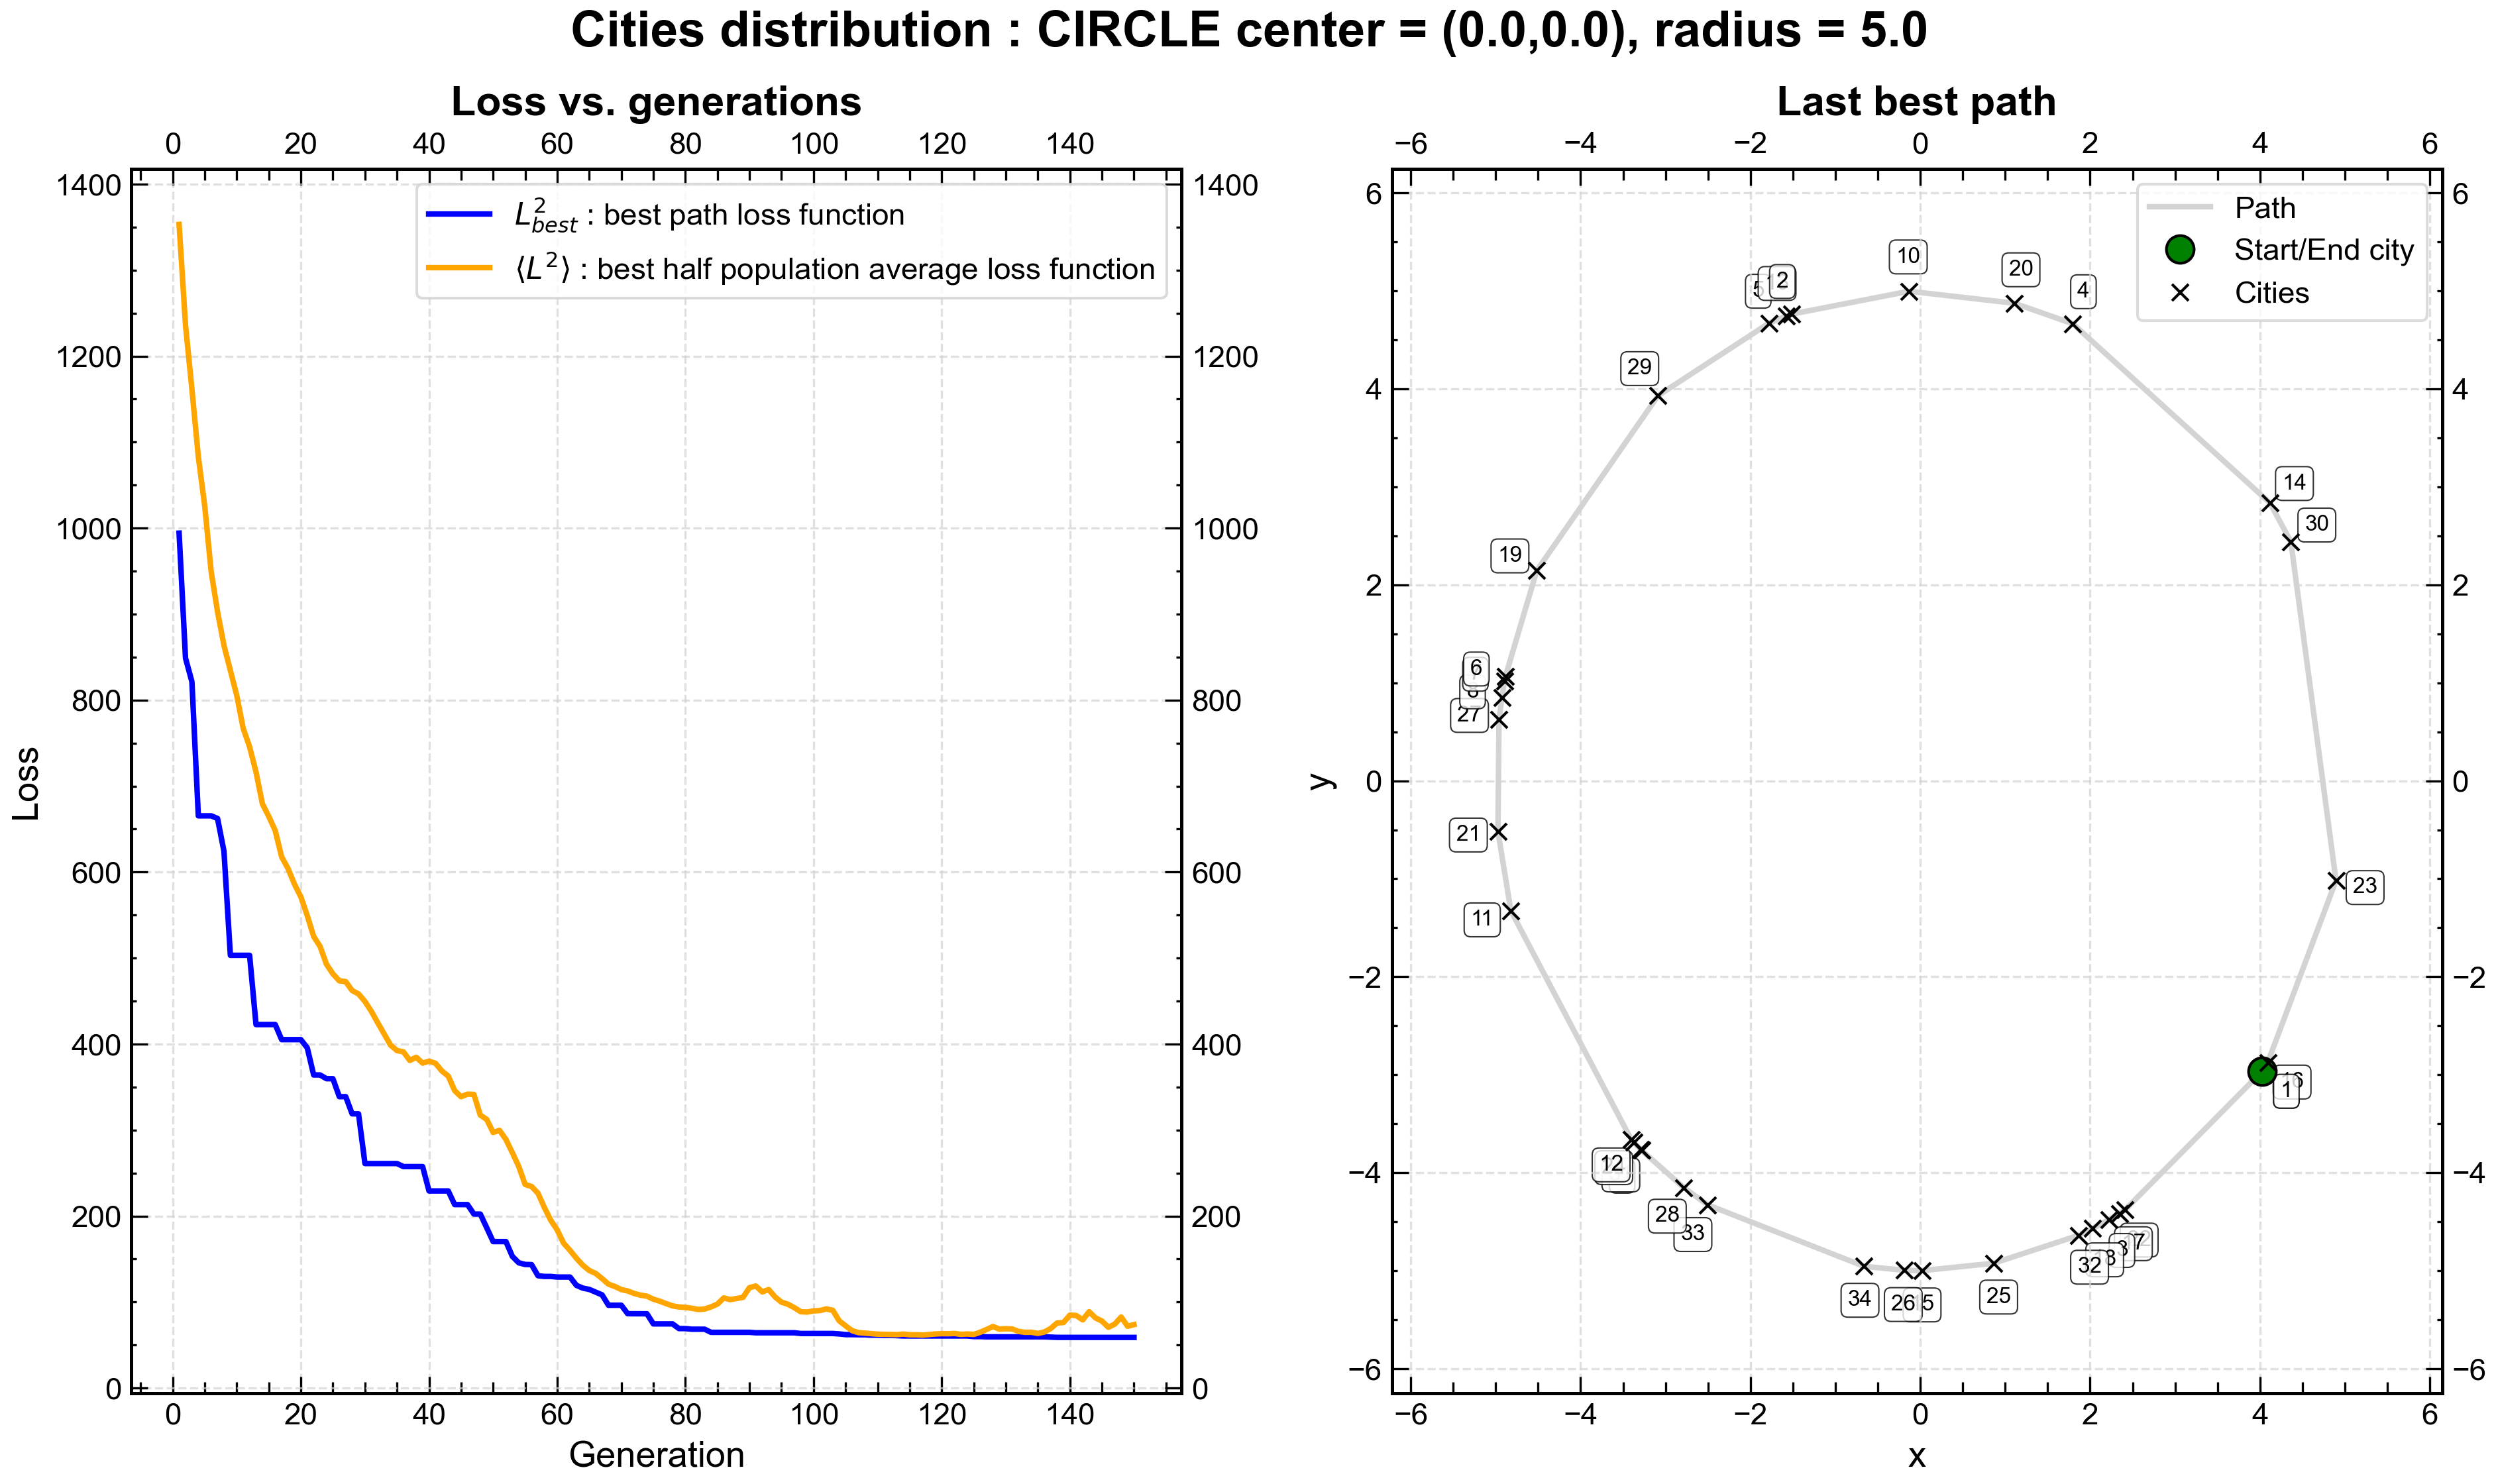

In [2]:
generations, best_loss = np.loadtxt("circle/OUTPUT/best_loss.dat", usecols=(0,1), unpack=True)
mean_loss = np.loadtxt("circle/OUTPUT/half_pop_mean_loss.dat", usecols=(1))
city_label, x,y = np.loadtxt('circle/OUTPUT/best_city_distribution.dat', usecols=(0,1,2), unpack=True)

x_center = 0.0
y_center = 0.0
radius = 5.0

margin = 1.25
x_min, x_max = x.min() - margin, x.max() + margin
y_min, y_max = y.min() - margin, y.max() + margin

fig, axs = plt.subplots(1,2,figsize=(15,8))
fig.suptitle(f"Cities distribution : CIRCLE center = ({x_center:.1f},{y_center:.1f}), radius = {radius:.1f}", fontweight='bold', fontsize=18)

axs[0].set_title("Loss vs. generations")
axs[0].plot(generations, best_loss, color='blue', label=r'$L^2_{best}$ : best path loss function')
axs[0].plot(generations, mean_loss, color='orange', label=r'$\langle L^2 \rangle$ : best half population average loss function')
axs[0].set_xlabel('Generation')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].set_title("Last best path")
axs[1].plot(x, y, color='lightgrey', label='Path')
axs[1].plot(x[0], y[0], color='green', linestyle='none', marker='o', markersize=10, markeredgecolor='black', label='Start/End city')
axs[1].plot(x[1:-1], y[1:-1], color='black', linestyle='none', marker='x', markersize=6, label='Cities')
for label,xi,yi in zip(city_label,x,y):
    theta = math.atan2(yi, xi)
    delta_x = 0.35 * math.cos(theta)
    delta_y = 0.35 * math.sin(theta)
    axs[1].text(xi + delta_x, yi + delta_y, int(label), fontsize=8, ha='center', va='center', zorder=1, bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', lw=0.5, alpha=0.8))
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].set_xlim(x_min, x_max)
axs[1].set_ylim(y_min, y_max)
axs[1].legend()

fig.savefig("circle/plot/loss_&_best_path.png")

plt.show()

animation_path = 'circle/plot/path_evolution.mp4'
Video(animation_path, embed=True)

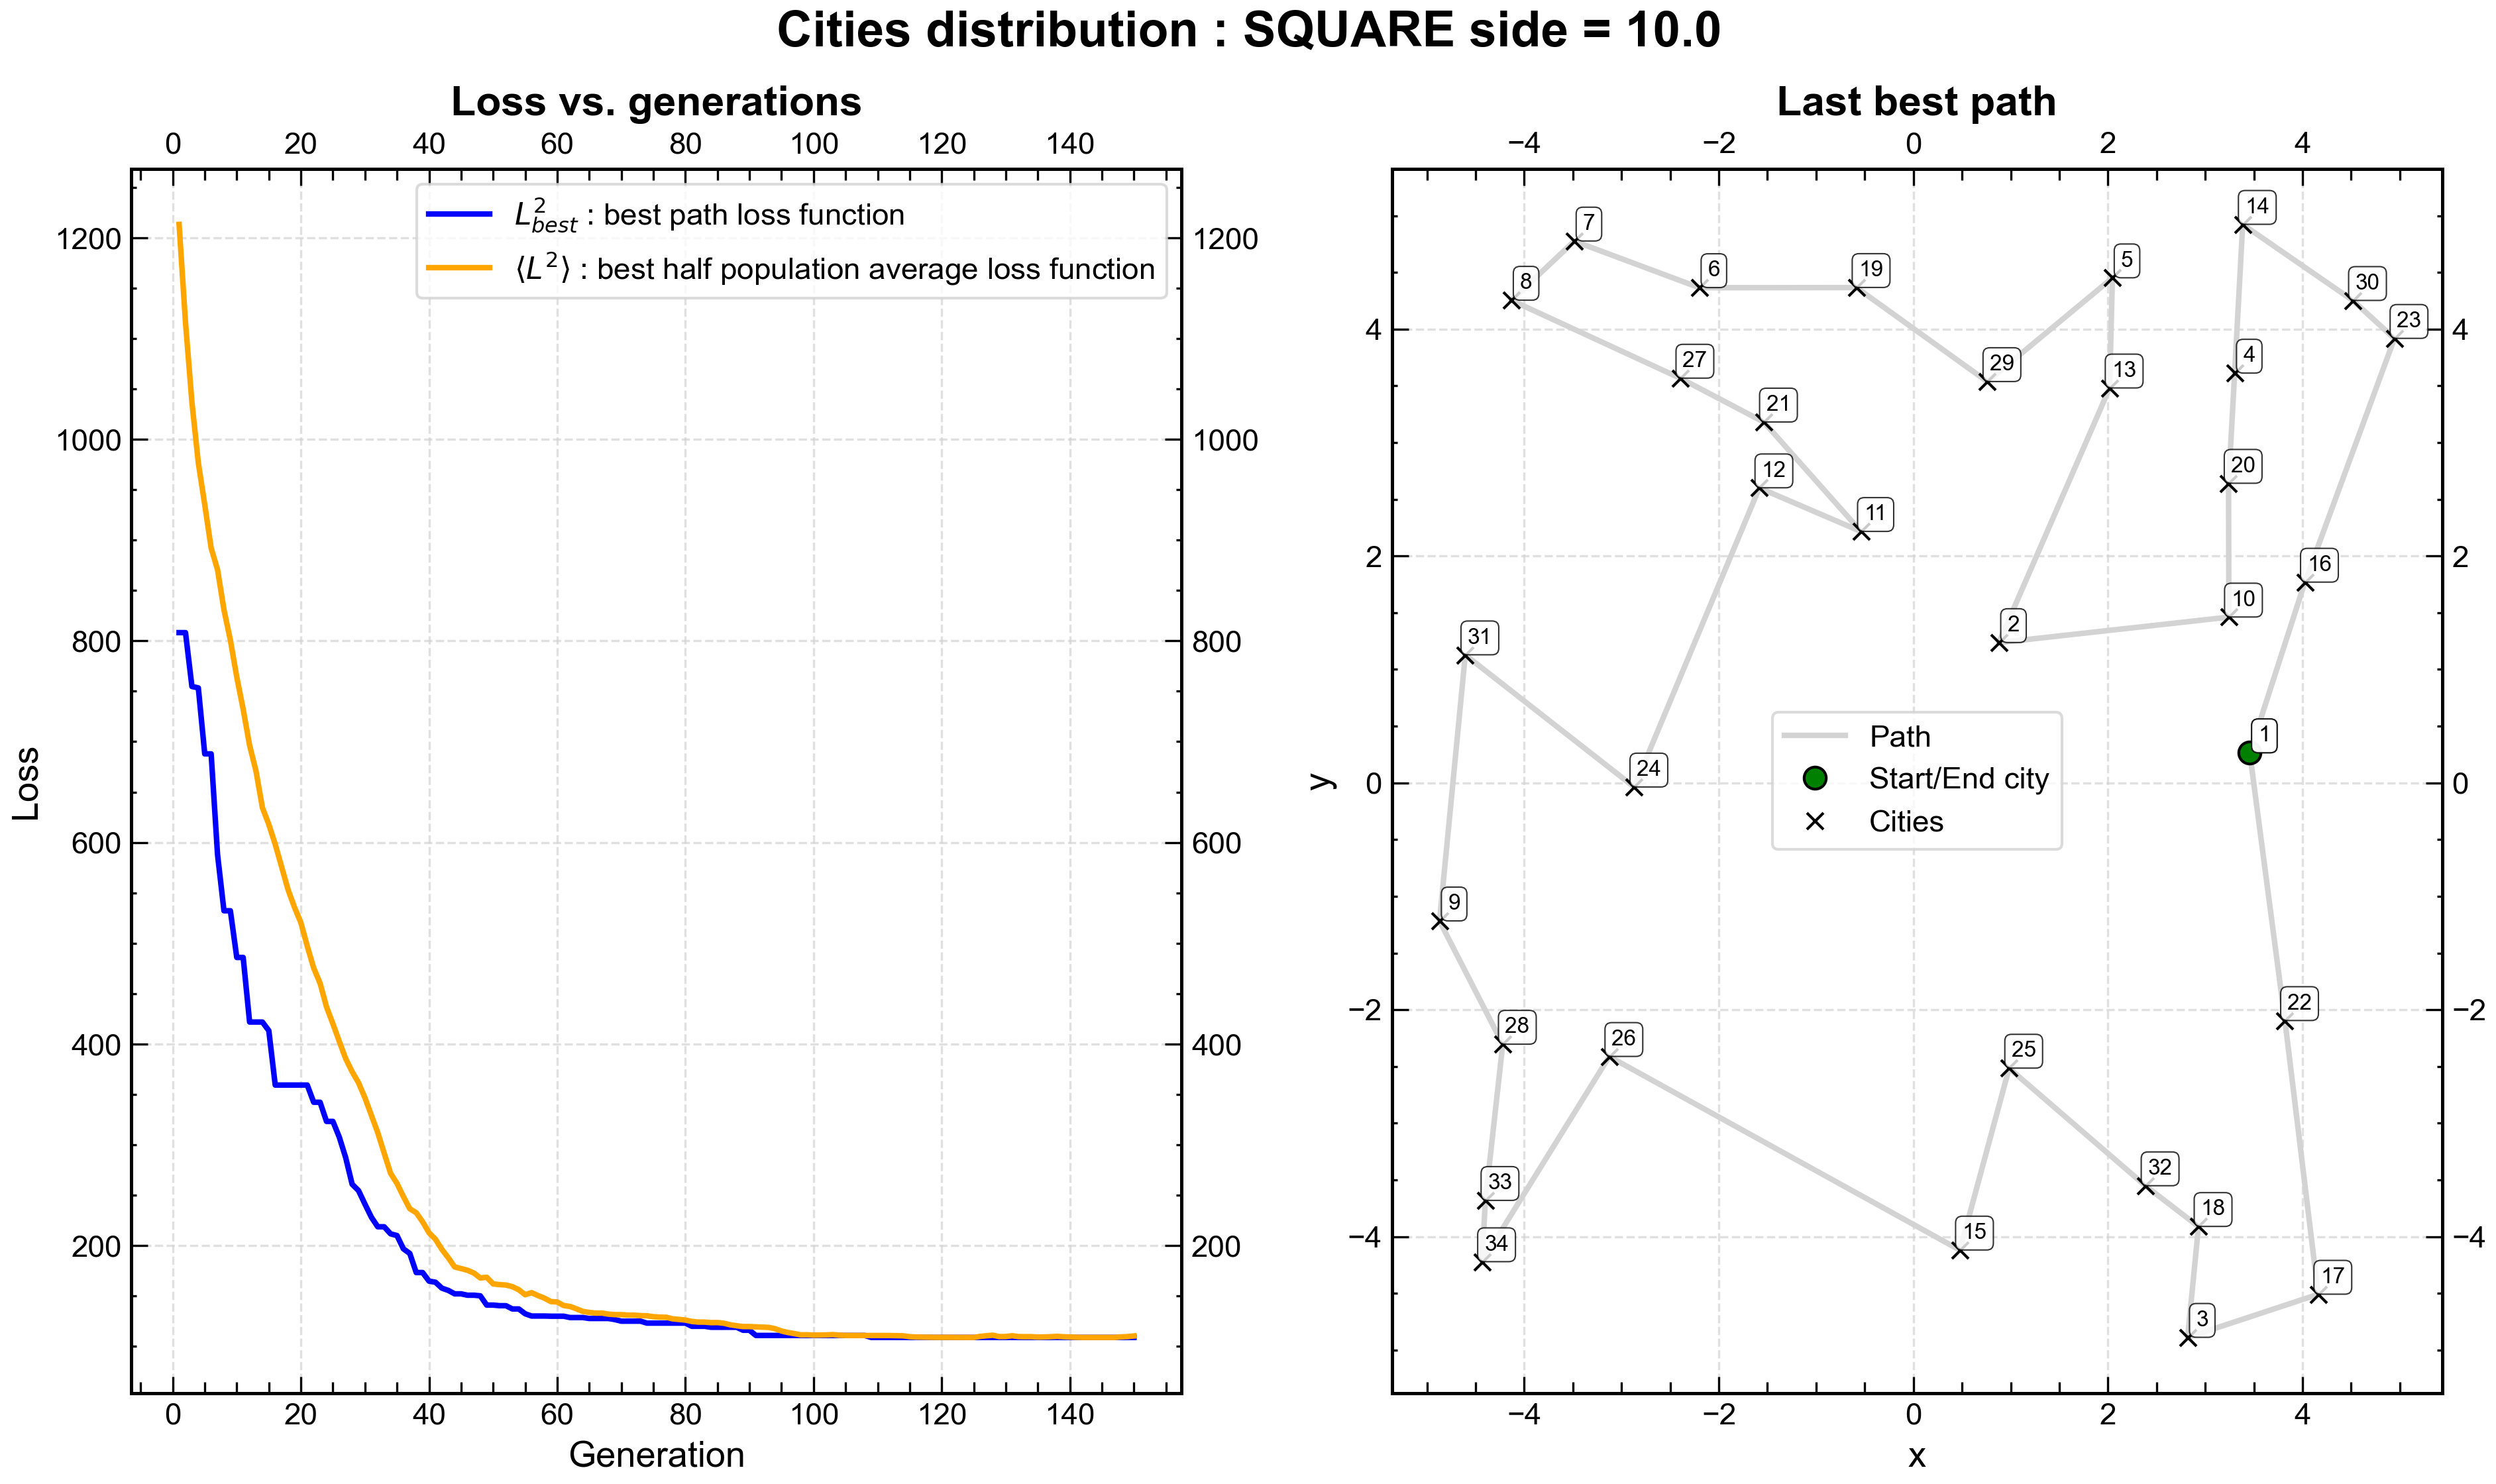

In [3]:
generations, best_loss = np.loadtxt("square/OUTPUT/best_loss.dat", usecols=(0,1), unpack=True)
mean_loss = np.loadtxt("square/OUTPUT/half_pop_mean_loss.dat", usecols=(1))
x,y = np.loadtxt('square/OUTPUT/best_city_distribution.dat', usecols=(1,2), unpack=True)

side = 10.0

margin = 1.25
x_min, x_max = x.min() - margin, x.max() + margin
y_min, y_max = y.min() - margin, y.max() + margin

fig, axs = plt.subplots(1,2,figsize=(15,8))
fig.suptitle(f"Cities distribution : SQUARE side = {side:.1f}", fontweight='bold', fontsize=18)

axs[0].set_title("Loss vs. generations")
axs[0].plot(generations, best_loss, color='blue', label=r'$L^2_{best}$ : best path loss function')
axs[0].plot(generations, mean_loss, color='orange', label=r'$\langle L^2 \rangle$ : best half population average loss function')
axs[0].set_xlabel('Generation')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].set_title("Last best path")
axs[1].plot(x, y, color='lightgrey', label='Path')
axs[1].plot(x[0], y[0], color='green', linestyle='none', marker='o', markersize=8, markeredgecolor='black', label='Start/End city')
axs[1].plot(x[1:-1], y[1:-1], color='blue', linestyle='none', marker='x', markersize=6, markeredgecolor='black', label='Cities')
for label,xi,yi in zip(city_label,x,y):
    delta_x = 0.15
    delta_y = 0.15
    axs[1].text(xi + delta_x, yi + delta_y, int(label), fontsize=8, ha='center', va='center', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', lw=0.5, alpha=0.8))
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].legend()

fig.savefig("square/plot/loss_&_best_path.png")

plt.show()

animation_path = 'square/plot/path_evolution.mp4'
Video(animation_path, embed=True)